In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import make_interp_spline
from helper import compute_poi_ul

import json
# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [2]:

csv_path = './slepLR_xsecs.csv'
with open(csv_path, 'r') as f:
    lines = [l for l in f.readlines() if l.strip() and not l.startswith('#')]

data = np.genfromtxt(lines, delimiter=",", names=True, dtype=float)
mass = np.atleast_1d(np.asarray(data['mass'], dtype=float))
xsec = np.atleast_1d(np.asarray(data['xsec'], dtype=float))
order = np.argsort(mass)
mass = mass[order]
xsec = xsec[order]

nloXsecF = make_interp_spline(mass, xsec,k=2)


### Create dataframe with all results

In [3]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

dfRecast['xsecNLO_slep_fb'] = nloXsecF(dfRecast['mLLP'])*1e3
dfRecast['kFactor'] = dfRecast['xsecNLO_slep_fb']/(dfRecast['Cross-Section (pb)']*1e3)

In [4]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_ee_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfSlep = pd.json_normalize(
    data,
    meta=columns
)

dfSlep['tau0_ns'] = (dfSlep['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfSlep['width_GeV'] = 6.582e-16/dfSlep['tau0_ns']

dfSlep['xsecNLO_slep_fb'] = nloXsecF(dfSlep['mLLP'])*1e3
dfSlep['kFactor'] = dfSlep['xsecNLO_slep_fb']/(dfSlep['Cross-Section (pb)']*1e3)

## Plot Efficiencies and MC Uncertainties

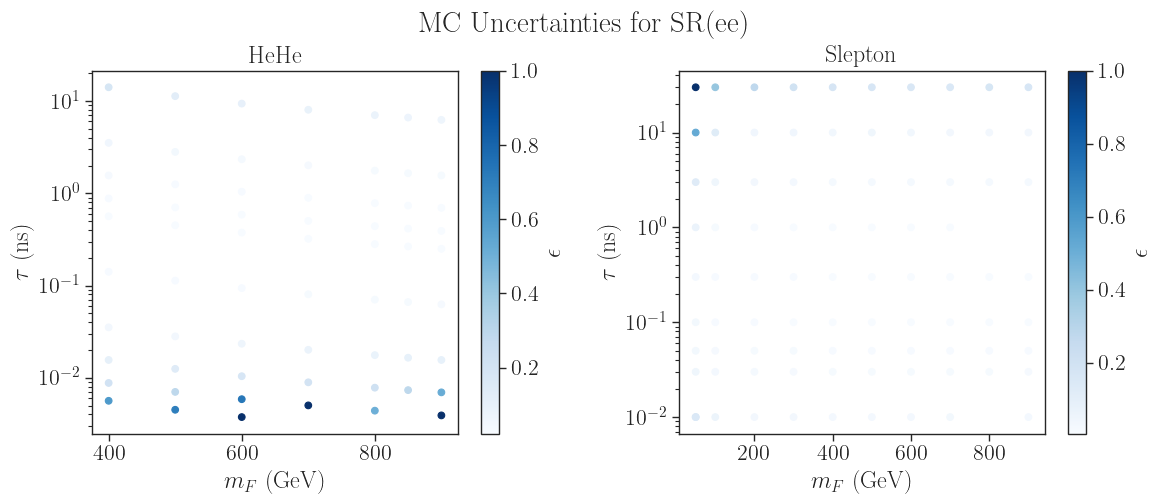

In [5]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
xDMList_all = list((dfRecast['m5000022']/dfRecast['mLLP']).unique())
xDM  = min(xDMList_all)

dfs = [dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM], dfSlep]
titles = ['HeHe', 'Slepton']
for iax,ax in enumerate(axList):
    df = dfs[iax]
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']

    im = ax.scatter(x,y,c=z,cmap='Blues')
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(titles[iax])

plt.tight_layout()
plt.suptitle('MC Uncertainties for SR(ee)', y=1.02)
plt.show()

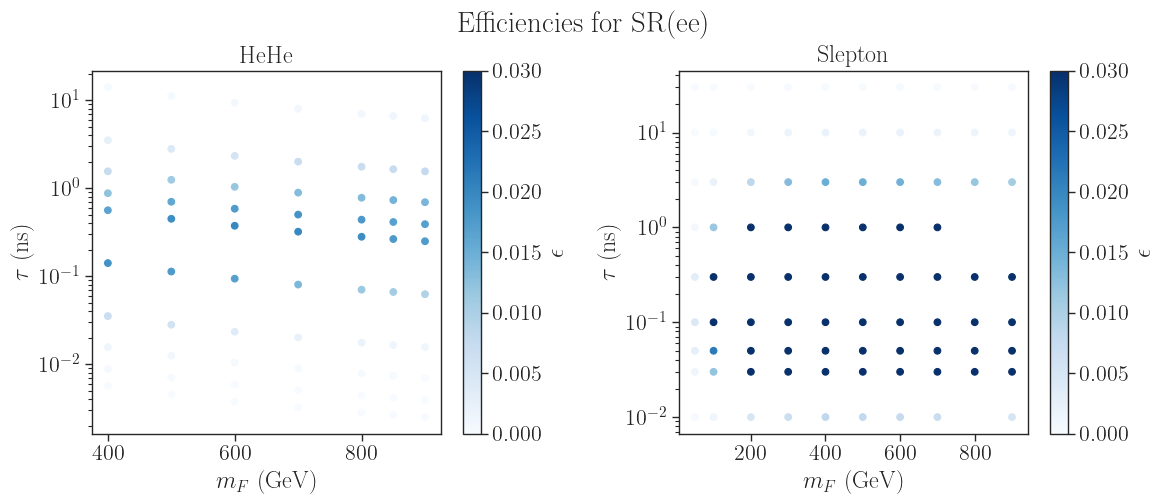

In [6]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
xDMList_all = list((dfRecast['m5000022']/dfRecast['mLLP']).unique())
xDM  = min(xDMList_all)

dfs = [dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM], dfSlep]
titles = ['HeHe', 'Slepton']
for iax,ax in enumerate(axList):
    df = dfs[iax]
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    z = df['AccEffCuts_ee']

    im = ax.scatter(x,y,c=z,cmap='Blues',vmin=0.,vmax=0.03)
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(titles[iax])

plt.tight_layout()
plt.suptitle('Efficiencies for SR(ee)', y=1.02)
plt.show()

## Compare efficiencies

,mLLP,tau0_ns,eff_hehe_interp,eff_slep_interp,ratio_hehe_over_slep
0,400.0,0.00563,0.000049,0.008121,0.006022
1,400.0,0.00879,0.000419,0.008121,0.051656
2,400.0,0.01560,0.001520,0.022428,0.067786
3,400.0,0.03520,0.006684,0.068289,0.097880
4,400.0,0.14100,0.018717,0.137972,0.135656
5,400.0,0.56300,0.016437,0.109898,0.149568
6,400.0,0.87900,0.012191,0.076447,0.159474
7,400.0,1.56000,0.007367,0.050039,0.147227
8,400.0,3.52000,0.002654,0.014088,0.188381
9,400.0,14.10000,0.000308,0.001555,0.198337


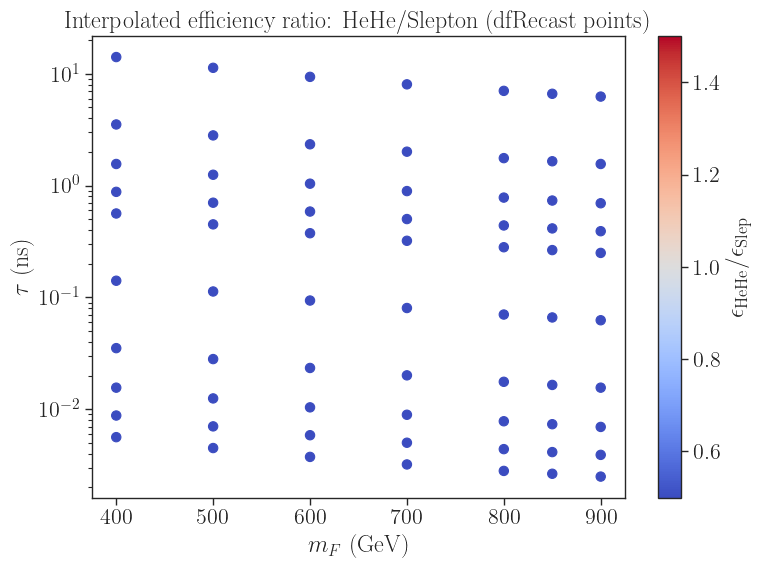

In [7]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

# Match the same kinematic slice used above for HeHe
xDM = min((dfRecast['m5000022'] / dfRecast['mLLP']).unique())
dfHeHe = dfRecast[dfRecast['m5000022'] / dfRecast['mLLP'] == xDM].copy()

# Keep only finite values
dfHeHe = dfHeHe[np.isfinite(dfHeHe['mLLP']) & np.isfinite(dfHeHe['tau0_ns']) & np.isfinite(dfHeHe['AccEffCuts_ee'])]
dfSlepClean = dfSlep[np.isfinite(dfSlep['mLLP']) & np.isfinite(dfSlep['tau0_ns']) & np.isfinite(dfSlep['AccEffCuts_ee'])].copy()

pts_hehe = np.column_stack([dfHeHe['mLLP'].to_numpy(dtype=float), dfHeHe['tau0_ns'].to_numpy(dtype=float)])
pts_slep = np.column_stack([dfSlepClean['mLLP'].to_numpy(dtype=float), dfSlepClean['tau0_ns'].to_numpy(dtype=float)])

eff_hehe = dfHeHe['AccEffCuts_ee'].to_numpy(dtype=float)
eff_slep = dfSlepClean['AccEffCuts_ee'].to_numpy(dtype=float)

# Interpolate Slepton efficiencies on the dfRecast points
interp_slep_lin = LinearNDInterpolator(pts_slep, eff_slep, fill_value=np.nan)
interp_slep_near = NearestNDInterpolator(pts_slep, eff_slep)

# Evaluate only at dfRecast points
m_common = pts_hehe[:, 0]
tau_common = pts_hehe[:, 1]
hehe_i = eff_hehe.copy()
slep_i = interp_slep_lin(m_common, tau_common)

mask_slep = ~np.isfinite(slep_i)
if np.any(mask_slep):
    slep_i[mask_slep] = interp_slep_near(m_common[mask_slep], tau_common[mask_slep])

ratio = np.divide(hehe_i, slep_i, out=np.full_like(hehe_i, np.nan), where=slep_i > 0)

dfRatio = pd.DataFrame({
    'mLLP': m_common,
    'tau0_ns': tau_common,
    'eff_hehe_interp': hehe_i,
    'eff_slep_interp': slep_i,
    'ratio_hehe_over_slep': ratio
}).sort_values(['mLLP', 'tau0_ns']).reset_index(drop=True)

display(dfRatio.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    dfRatio['mLLP'],
    dfRatio['tau0_ns'],
    c=dfRatio['ratio_hehe_over_slep'],
    cmap='coolwarm',
    vmin=0.5,
    vmax=1.5,
    s=45
    )
ax.set_yscale('log')
ax.set_xlabel(r'$m_F$ (GeV)')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_title(r'Interpolated efficiency ratio: HeHe/Slepton (dfRecast points)')
fig.colorbar(sc, ax=ax, label=r'$\epsilon_{\mathrm{HeHe}}/\epsilon_{\mathrm{Slep}}$')
plt.tight_layout()
plt.show()